In [11]:
# =============================================================================
# Zelle 01 – Setup & Daten laden
# =============================================================================
# Preprocessing Modell A. Referenzvariable X_A_MERKMALE aus Notebook 03
# (Nachtrag 2) uebernommen - nur echte Prozessparameter, die vor der
# Fertigung bekannt sind. Y_A-Qualitaetsmesswerte dienen ausschliesslich
# der Zielgroessen-Konstruktion, nicht als Modell-Input.
# =============================================================================

import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE

SEED = 42
apply_store44_style()

# --- Rohdaten laden (raw wird nie veraendert) ---
df_raw = pd.read_csv("../data/raw/model_a_raw.csv")
df_latent_ref = pd.read_csv("../data/raw/model_a_latent_reference.csv")

# --- Arbeitskopie ---
df = df_raw.copy()

X_A_MERKMALE = [
    "schneckendrehzahl", "massedurchsatz", "massetemperatur", "massedruck",
    "duesenspalt", "abzugsgeschwindigkeit", "kalibrierdruck_mbar",
    "kuehlwassertemperatur", "mfr_charge",
]

print(f"df_raw shape: {df_raw.shape}")
print(f"X_A_MERKMALE ({len(X_A_MERKMALE)}): {X_A_MERKMALE}")
print(f"\nFehlende Werte in X_A_MERKMALE:")
print(df[X_A_MERKMALE].isna().sum())

df_raw shape: (700, 22)
X_A_MERKMALE (9): ['schneckendrehzahl', 'massedurchsatz', 'massetemperatur', 'massedruck', 'duesenspalt', 'abzugsgeschwindigkeit', 'kalibrierdruck_mbar', 'kuehlwassertemperatur', 'mfr_charge']

Fehlende Werte in X_A_MERKMALE:
schneckendrehzahl         0
massedurchsatz            0
massetemperatur           0
massedruck                0
duesenspalt               0
abzugsgeschwindigkeit     0
kalibrierdruck_mbar       0
kuehlwassertemperatur    31
mfr_charge               28
dtype: int64


Fehlende Werte nach Imputation:
kuehlwassertemperatur    0
mfr_charge               0
dtype: int64

Imputationswerte (Median): {'kuehlwassertemperatur': np.float64(16.185440304998824), 'mfr_charge': np.float64(0.6866549239034574)}


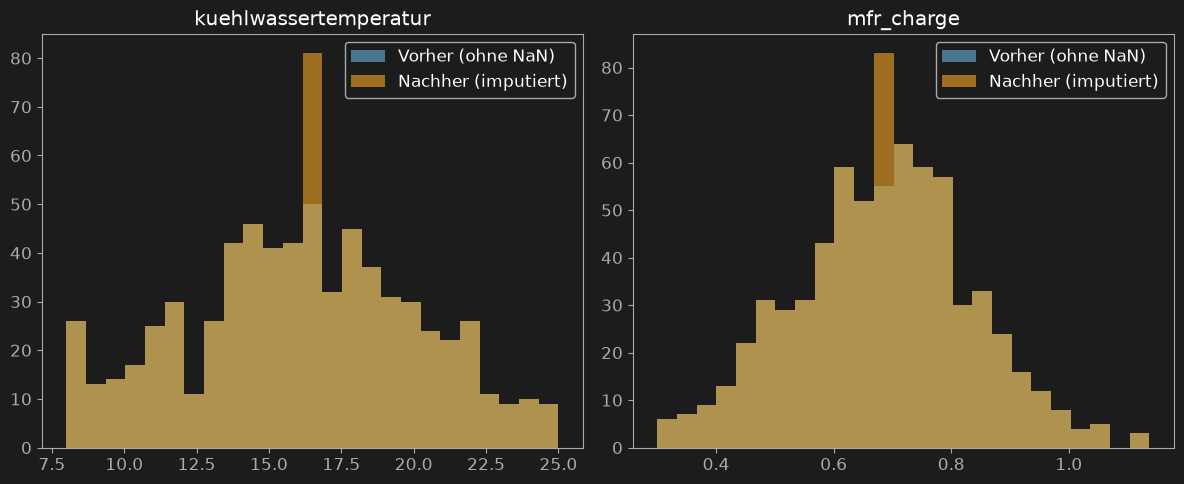

In [12]:
# =============================================================================
# Zelle 02 – Imputation der MCAR-Spalten (kuehlwassertemperatur, mfr_charge)
# =============================================================================
# EDA-Ergebnis (Notebook 03, Zelle 09c): beobachtete vs. erwartete
# Kombinationsquote nahezu identisch (16.3% vs. 16.1%), keine Ko-Auftretens-
# Haeufung - echtes MCAR, einfache Imputation methodisch vertretbar.
# Median statt Mean gewaehlt (robuster gegen die in Notebook 03 festgestellte
# Rechtsschiefe vieler Merkmale, siehe Skewness-Werte Zelle 06).
# =============================================================================

from sklearn.impute import SimpleImputer

MCAR_SPALTEN = ["kuehlwassertemperatur", "mfr_charge"]

imputer = SimpleImputer(strategy="median")
df[MCAR_SPALTEN] = imputer.fit_transform(df[MCAR_SPALTEN])

print("Fehlende Werte nach Imputation:")
print(df[MCAR_SPALTEN].isna().sum())
print(f"\nImputationswerte (Median): {dict(zip(MCAR_SPALTEN, imputer.statistics_))}")

# --- Vorher/Nachher-Validierung: Verteilung darf sich nicht signifikant verschieben ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, MCAR_SPALTEN):
    ax.hist(df_raw[col].dropna(), bins=25, alpha=0.6, label="Vorher (ohne NaN)", color=COLOR_BLUE)
    ax.hist(df[col], bins=25, alpha=0.6, label="Nachher (imputiert)", color=COLOR_GOLD)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
save_figure(fig, "../reports/figures/04_preprocessing_imputation_vergleich.png")
plt.show()

=== Vergleich: Original vs. Median- vs. KNN-Imputation ===
                            Original (ohne NaN)  Median-Imputation  \
mean kuehlwassertemperatur               16.131             16.133   
     mfr_charge                           0.683              0.684   
std  kuehlwassertemperatur                3.998              3.908   
     mfr_charge                           0.152              0.149   
min  kuehlwassertemperatur                8.000              8.000   
     mfr_charge                           0.300              0.300   
max  kuehlwassertemperatur               25.000             25.000   
     mfr_charge                           1.137              1.137   

                            KNN-Imputation  
mean kuehlwassertemperatur          16.126  
     mfr_charge                      0.682  
std  kuehlwassertemperatur           3.920  
     mfr_charge                      0.151  
min  kuehlwassertemperatur           8.000  
     mfr_charge                      0.3

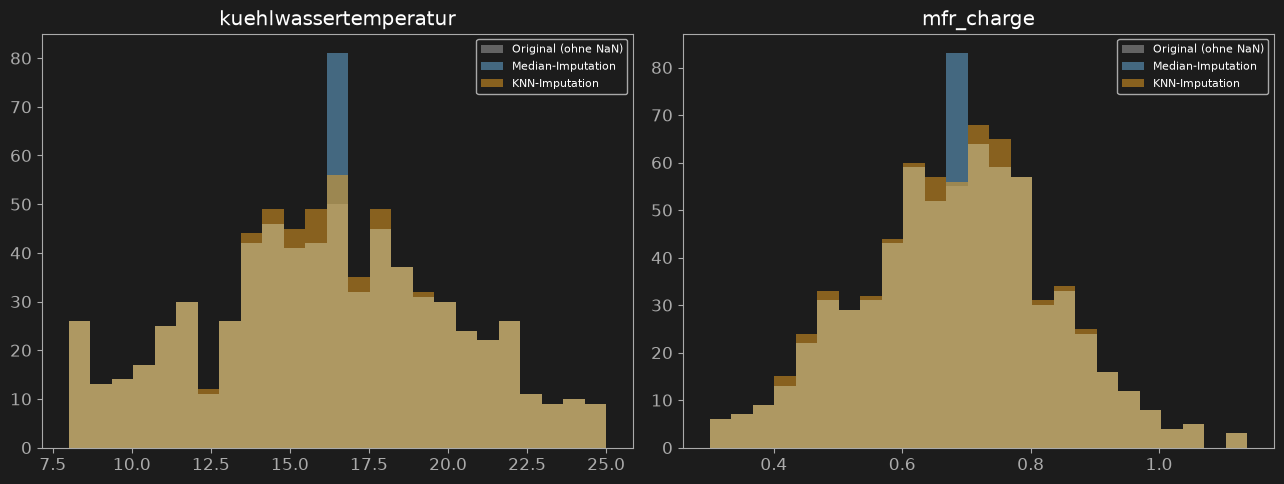


-> Kriterium fuer Entscheidung: Std-Abweichung sollte durch Imputation
   moeglichst wenig verzerrt werden (naeher am Original = besser).


In [13]:
# =============================================================================
# Zelle 02b – Vergleich: KNN-Imputation statt Median
# =============================================================================
# Anlass: Median-Imputation erzeugt sichtbaren kuenstlichen "Spike" (siehe
# Histogramm Zelle 02) - alle fehlenden Werte erhalten identischen Wert,
# was Varianz und Verteilungsform verzerrt. KNN-Imputation nutzt stattdessen
# die Aehnlichkeit zu anderen X_A-Merkmalen (z. B. mfr_charge korreliert mit
# massedruck, r=-0.74 laut Notebook 03 Zelle 19) fuer realistischere,
# individuelle Schaetzwerte je Zeile.
# =============================================================================

from sklearn.impute import KNNImputer

df_knn = df_raw.copy()

# KNN nutzt alle X_A-Merkmale gemeinsam (auch die vollstaendigen), um
# Aehnlichkeit zwischen Zeilen zu bestimmen - nicht nur die Zielspalte selbst
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[X_A_MERKMALE] = knn_imputer.fit_transform(df_knn[X_A_MERKMALE])

# --- Statistischer Vergleich: Verteilungskennzahlen ---
vergleich = pd.DataFrame({
    "Original (ohne NaN)": df_raw[MCAR_SPALTEN].describe().loc[["mean", "std", "min", "max"]].stack(),
    "Median-Imputation": df[MCAR_SPALTEN].describe().loc[["mean", "std", "min", "max"]].stack(),
    "KNN-Imputation": df_knn[MCAR_SPALTEN].describe().loc[["mean", "std", "min", "max"]].stack(),
})
print("=== Vergleich: Original vs. Median- vs. KNN-Imputation ===")
print(vergleich.round(3))

# --- Visueller Vergleich: alle drei Verteilungen ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, MCAR_SPALTEN):
    ax.hist(df_raw[col].dropna(), bins=25, alpha=0.5, label="Original (ohne NaN)", color=COLOR_TEXT_MUTED)
    ax.hist(df[col], bins=25, alpha=0.5, label="Median-Imputation", color=COLOR_BLUE)
    ax.hist(df_knn[col], bins=25, alpha=0.5, label="KNN-Imputation", color=COLOR_GOLD)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, "../reports/figures/04_preprocessing_imputation_vergleich_median_vs_knn.png")
plt.show()

print("\n-> Kriterium fuer Entscheidung: Std-Abweichung sollte durch Imputation")
print("   moeglichst wenig verzerrt werden (naeher am Original = besser).")

In [14]:
# =============================================================================
# Zelle 02c – Finalisierung: KNN-Imputation als gewaehlte Methode uebernehmen
# =============================================================================
# Entscheidung basierend auf Vergleich in Zelle 02b: KNN naeher am Original
# in Std-Abweichung (siehe Tabelle), kein kuenstlicher Verteilungs-Spike.
# df wird ab hier mit den bereits in Zelle 02b berechneten KNN-imputierten
# Werten ueberschrieben - Median-Ergebnis (Zelle 02) bleibt zur
# Nachvollziehbarkeit im Notebook erhalten, wird aber nicht weiterverwendet.
#
# WICHTIG fuer Notebook 05/06 (Pipeline-Aufbau): KNNImputer darf dort NUR auf
# Trainingsdaten gefittet werden (.fit_transform auf Train, .transform auf
# Test) - sonst Data Leakage. Hier in der Preprocessing-Exploration wird auf
# dem Gesamtdatensatz gearbeitet (noch kein Train/Test-Split), das ist an
# dieser Stelle unproblematisch, muss aber im Pipeline-Schritt korrekt
# nachgeholt werden.
# =============================================================================

df[X_A_MERKMALE] = df_knn[X_A_MERKMALE]

print("Finalisiert: df nutzt KNN-imputierte Werte fuer X_A_MERKMALE.")
print("\nFehlende Werte nach Finalisierung:")
print(df[MCAR_SPALTEN].isna().sum())

Finalisiert: df nutzt KNN-imputierte Werte fuer X_A_MERKMALE.

Fehlende Werte nach Finalisierung:
kuehlwassertemperatur    0
mfr_charge               0
dtype: int64


In [15]:
# =============================================================================
# Zelle 03 – Delamination-Sonderbehandlung (MNAR, maskierter Ansatz)
# =============================================================================
# KORREKTUR ggue. erstem Versuch: keine Fake-Kategorie "nicht_anwendbar"
# (waere fuer ein Modell nur ein drittes beliebiges Label, semantisch falsch
# und wuerde bei naiver 3-Klassen-Nutzung triviale Scheingenauigkeit
# erzeugen). Stattdessen: binaeres Ziel bleibt binaer (NaN bleibt NaN),
# zusaetzliche Anwendbarkeits-Flag-Spalte fuer maskiertes Training/
# Auswertung (Standardtechnik bei partiell anwendbaren Multi-Label-Zielen).
# ZUSATZFUND: wandtyp fehlte bisher in X_A_MERKMALE, obwohl vor Fertigung
# bekannt und fuer Fehlermechanismen relevant - wird hier ergaenzt.
# =============================================================================

# Anwendbarkeits-Flag (fuer maskiertes Training/Auswertung des Delamination-Labels)
df["delamination_anwendbar"] = (df["wandtyp"] == "doppelwandig").astype(int)

# delamination bleibt numerisch/binaer, NaN bleibt NaN (keine Fake-Kategorie)
print("Delamination-Werte (dropna=False, damit NaN sichtbar bleibt):")
print(df["delamination"].value_counts(dropna=False))

print("\nAnwendbarkeits-Flag:")
print(df["delamination_anwendbar"].value_counts())

print("\nKonsistenz-Check: delamination_anwendbar vs. tatsaechliche NaN-Verteilung")
print(pd.crosstab(df["delamination_anwendbar"], df["delamination"].isna()))

# wandtyp als vollwertiges X_A-Merkmal ergaenzen (Korrektur des Uebersehens)
X_A_MERKMALE.append("wandtyp")
print(f"\nX_A_MERKMALE aktualisiert ({len(X_A_MERKMALE)}): {X_A_MERKMALE}")

Delamination-Werte (dropna=False, damit NaN sichtbar bleibt):
delamination
NaN    514
0.0    180
1.0      6
Name: count, dtype: int64

Anwendbarkeits-Flag:
delamination_anwendbar
0    514
1    186
Name: count, dtype: int64

Konsistenz-Check: delamination_anwendbar vs. tatsaechliche NaN-Verteilung
delamination            False  True 
delamination_anwendbar              
0                           0    514
1                         186      0

X_A_MERKMALE aktualisiert (10): ['schneckendrehzahl', 'massedurchsatz', 'massetemperatur', 'massedruck', 'duesenspalt', 'abzugsgeschwindigkeit', 'kalibrierdruck_mbar', 'kuehlwassertemperatur', 'mfr_charge', 'wandtyp']


In [16]:
# =============================================================================
# Zelle 04 – DN-Proxy (aus X_A) und Residual-Features
# =============================================================================
# WICHTIG: Ursprungsidee "Abweichung von Sollwert" (z.B. wandstaerke_ist -
# wandstaerke_ideal_latent) ist NICHT mehr zulaessig - wandstaerke_ist ist
# Y_A, dessen Verwendung als Feature genau das in Notebook 03 (Nachtrag 2)
# korrigierte X_A/Y_A-Leck waere.
# Sauberer Ersatz: DN-Proxy wird AUSSCHLIESSLICH aus X_A_MERKMALE berechnet
# (PC1, korreliert mit rohr_dn_latent mit r=0.984, siehe Notebook 03 Zelle
# 20b - aber die latente Groesse selbst wird hier nie verwendet). Fuer jedes
# numerische X_A-Merkmal wird der NICHT durch die Baugroesse erklaerte
# Anteil (Residuum) berechnet - isoliert die lokale Variation, die laut EDA
# das eigentlich NIO-relevante Signal traegt (PC1 selbst zeigte keine
# IO/NIO-Trennkraft, Silhouette=0.017).
# =============================================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X_A_NUMERISCH = [c for c in X_A_MERKMALE if c != "wandtyp"]

scaler_dn = StandardScaler()
X_scaled_dn = scaler_dn.fit_transform(df[X_A_NUMERISCH])

pca_dn = PCA(n_components=1, random_state=SEED)
df["dn_proxy"] = pca_dn.fit_transform(X_scaled_dn).flatten()

print(f"DN-Proxy (PC1 aus X_A) erklaert {pca_dn.explained_variance_ratio_[0]*100:.1f}% Varianz")

# --- Residual-Features: baugroessenbereinigte Variation je Merkmal ---
residual_features = []
for col in X_A_NUMERISCH:
    lr = LinearRegression()
    lr.fit(df[["dn_proxy"]], df[col])
    residuum = df[col] - lr.predict(df[["dn_proxy"]])
    neue_spalte = f"{col}_dn_bereinigt"
    df[neue_spalte] = residuum
    residual_features.append(neue_spalte)
    r2 = lr.score(df[["dn_proxy"]], df[col])
    print(f"  {col:25s} R² durch DN-Proxy erklaert: {r2:.3f}")

print(f"\n{len(residual_features)} Residual-Features erzeugt: {residual_features}")

DN-Proxy (PC1 aus X_A) erklaert 48.2% Varianz
  schneckendrehzahl         R² durch DN-Proxy erklaert: 0.913
  massedurchsatz            R² durch DN-Proxy erklaert: 0.970
  massetemperatur           R² durch DN-Proxy erklaert: 0.000
  massedruck                R² durch DN-Proxy erklaert: 0.028
  duesenspalt               R² durch DN-Proxy erklaert: 0.886
  abzugsgeschwindigkeit     R² durch DN-Proxy erklaert: 0.952
  kalibrierdruck_mbar       R² durch DN-Proxy erklaert: 0.574
  kuehlwassertemperatur     R² durch DN-Proxy erklaert: 0.005
  mfr_charge                R² durch DN-Proxy erklaert: 0.013

9 Residual-Features erzeugt: ['schneckendrehzahl_dn_bereinigt', 'massedurchsatz_dn_bereinigt', 'massetemperatur_dn_bereinigt', 'massedruck_dn_bereinigt', 'duesenspalt_dn_bereinigt', 'abzugsgeschwindigkeit_dn_bereinigt', 'kalibrierdruck_mbar_dn_bereinigt', 'kuehlwassertemperatur_dn_bereinigt', 'mfr_charge_dn_bereinigt']


In [18]:
# =============================================================================
# Zelle 05 – Validierung: IO/NIO-Trennkraft der Residual-Features vs. Original
# =============================================================================
# Test der Blocker-C-Hypothese aus Notebook 03: verbessern die DN-bereinigten
# Residuen die Trennbarkeit gegenueber den Original-X_A-Werten?
# =============================================================================

from scipy.stats import kruskal
from sklearn.metrics import silhouette_score

residual_cols = [c for c in df.columns if c.endswith("_dn_bereinigt")]

print("=== Kruskal-Wallis: Residual-Features vs. io_nio ===")
kw_results_resid = []
for col in residual_cols:
    data_io = df.loc[df["io_nio"] == "IO", col].dropna()
    data_nio = df.loc[df["io_nio"] == "NIO", col].dropna()
    stat, p = kruskal(data_io, data_nio)
    kw_results_resid.append({"Merkmal": col, "H_Statistik": round(stat, 2), "p_Wert": round(p, 4), "Signifikant": p < 0.05})

kw_resid_summary = pd.DataFrame(kw_results_resid).sort_values("p_Wert")
print(kw_resid_summary.to_string(index=False))
print(f"\nSignifikant: {kw_resid_summary['Signifikant'].sum()} von {len(residual_cols)}")
print(f"(Vergleich Original X_A_MERKMALE, Notebook 03 Zelle 18: 5 von 9 signifikant)")

# --- Silhouette-Score: nur Residual-Features ---
df_resid_basis = df[residual_cols].dropna()
io_nio_resid = df.loc[df_resid_basis.index, "io_nio"]

scaler_resid = StandardScaler()
X_scaled_resid = scaler_resid.fit_transform(df_resid_basis)

pca_resid = PCA(n_components=min(6, len(residual_cols)), random_state=SEED)
X_pca_resid = pca_resid.fit_transform(X_scaled_resid)
n_komp_90 = np.argmax(np.cumsum(pca_resid.explained_variance_ratio_) >= 0.90) + 1

sil_score_resid = silhouette_score(X_pca_resid[:, :n_komp_90], (io_nio_resid == "NIO").astype(int))
print(f"\nSilhouette-Score (Residual-Features, {n_komp_90} Komponenten): {sil_score_resid:.4f}")
print(f"(Vergleich Original X_A_MERKMALE, Notebook 03 Zelle 20: 0.017)")

kw_resid_summary.to_csv("../reports/tables/04_preprocessing_kruskal_residual_features.csv", index=False)

=== Kruskal-Wallis: Residual-Features vs. io_nio ===
                           Merkmal  H_Statistik  p_Wert  Signifikant
  kalibrierdruck_mbar_dn_bereinigt        12.62  0.0004         True
          duesenspalt_dn_bereinigt        10.61  0.0011         True
    schneckendrehzahl_dn_bereinigt         6.60  0.0102         True
           massedruck_dn_bereinigt         4.12  0.0424         True
           mfr_charge_dn_bereinigt         2.26  0.1326        False
      massetemperatur_dn_bereinigt         1.79  0.1805        False
       massedurchsatz_dn_bereinigt         1.42  0.2327        False
kuehlwassertemperatur_dn_bereinigt         0.86  0.3532        False
abzugsgeschwindigkeit_dn_bereinigt         0.10  0.7531        False

Signifikant: 4 von 9
(Vergleich Original X_A_MERKMALE, Notebook 03 Zelle 18: 5 von 9 signifikant)

Silhouette-Score (Residual-Features, 6 Komponenten): 0.0152
(Vergleich Original X_A_MERKMALE, Notebook 03 Zelle 20: 0.017)
